In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
read= pd.read_csv("Mall_Customers.csv")

In [6]:
read.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [8]:
read.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [9]:
x= read[["Annual Income (k$)","Spending Score (1-100)"]]

In [10]:
scaler= StandardScaler()
x_scaled= scaler.fit_transform(x)


10


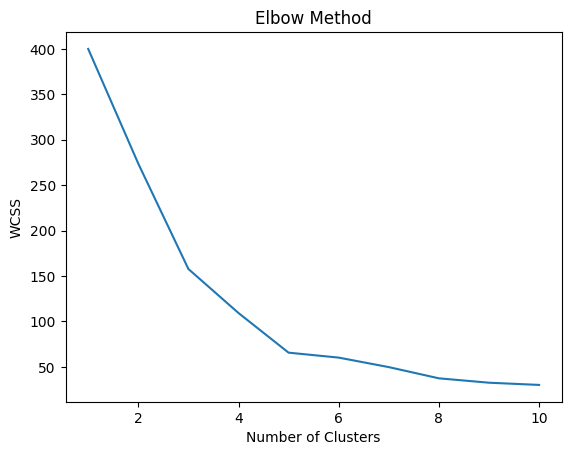

In [15]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

print(len(wcss))  

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [16]:
kmeans= KMeans(n_clusters=5, random_state=42)
clusters= kmeans.fit_predict(x_scaled)

In [17]:
read['cluster'] = clusters

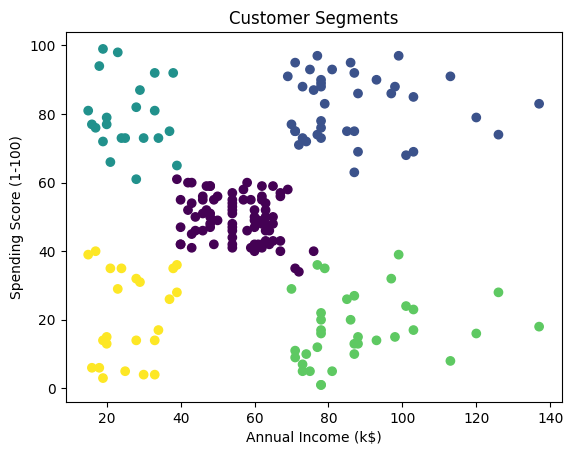

In [18]:
plt.scatter(read['Annual Income (k$)'],
            read['Spending Score (1-100)'], 
            c=read['cluster'], cmap='viridis')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

In [19]:
read.groupby('cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [20]:
from sklearn.cluster import DBSCAN

In [21]:
dbscan= DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters= dbscan.fit_predict(x_scaled)
read['dbscan_cluster'] = dbscan_clusters

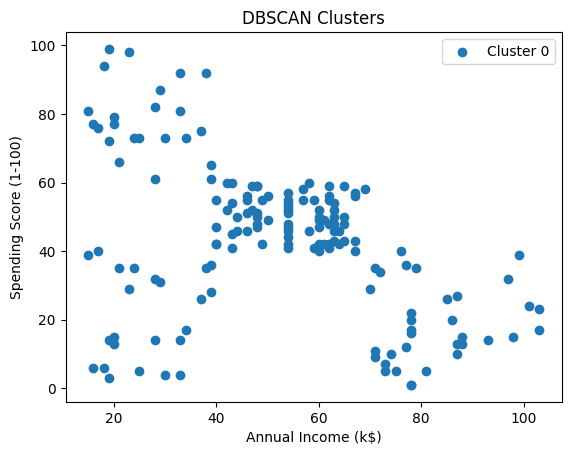

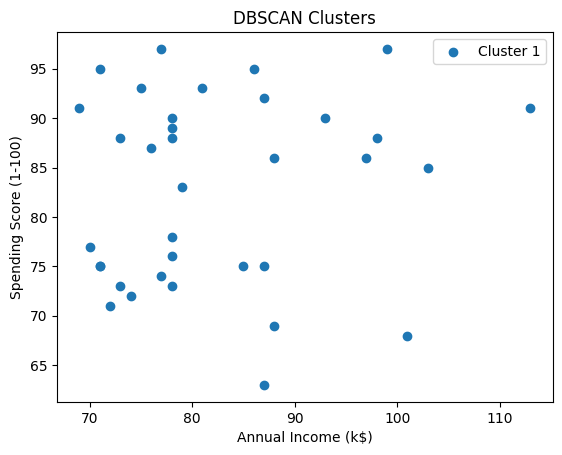

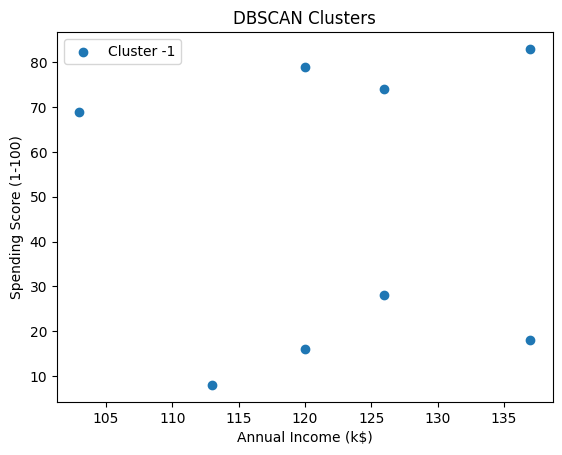

In [24]:
for cluster in read['dbscan_cluster'].unique():
    subset = read[read['dbscan_cluster'] == cluster]
    plt.scatter(subset['Annual Income (k$)'], 
                subset['Spending Score (1-100)'], 
                label=f'Cluster {cluster}')
    
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score (1-100)")
    plt.title("DBSCAN Clusters")
    plt.legend()
    plt.show()